# ***Heart Disease Dataset***

* **Author Name:** Tuhid Khan
* **Email:** tuhidkhan1202@gmail.com



## About the Dataset
This dataset dates back to 1988 and combines patient data across four medical institutions: Cleveland, Hungary, Switzerland, and Long Beach V. While the original database contains 76 raw attributes, this widely utilized subset focuses on 14 key clinical variables essential for predicting cardiovascular health. 

Primary objectives typically include:
- Performing Exploratory Data Analysis (EDA) on physiological risk factors (e.g., age, cholesterol, resting blood pressure) associated with heart disease.
- Building classification models (e.g., Logistic Regression, Random Forest, Support Vector Machines) to predict the presence (`1`) or absence (`0`) of heart disease.

---

## Dataset Overview & Metadata

- **Source / Dataset:** [Kaggle - Heart Disease Dataset](https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset)
- **Primary File Name:** `heart.csv`
- **File Size:** ~38.1 KB
- **License:** Unknown / Public Domain (Original data sourced from UCI Machine Learning Repository)
- **Dataset Shape:** 1,025 Rows × 14 Columns

---

## Data Schema & Variable Description

| Column Name | Data Type | Description |
| :--- | :--- | :--- |
| `age` | Integer | Age of the patient in years |
| `sex` | Categorical (0/1) | Gender of the patient (`1` = Male, `0` = Female) |
| `cp` | Categorical (0–3) | Chest pain type (`0` = Typical Angina, `1` = Atypical Angina, `2` = Non-anginal pain, `3` = Asymptomatic) |
| `trestbps` | Integer / Float | Resting blood pressure (in mm Hg on admission to the hospital) |
| `chol` | Integer / Float | Serum cholesterol level in mg/dl |
| `fbs` | Categorical (0/1) | Fasting blood sugar > 120 mg/dl (`1` = True, `0` = False) |
| `restecg` | Categorical (0–2) | Resting electrocardiographic results (`0` = Normal, `1` = ST-T wave abnormality, `2` = Showing probable/definite left ventricular hypertrophy) |
| `thalach` | Integer / Float | Maximum heart rate achieved during testing |
| `exang` | Categorical (0/1) | Exercise-induced angina (`1` = Yes, `0` = No) |
| `oldpeak` | Float | ST depression induced by exercise relative to rest |
| `slope` | Categorical (0–2) | The slope of the peak exercise ST segment (`0` = Upsloping, `1` = Flat, `2` = Downsloping) |
| `ca` | Integer (0–4) | Number of major vessels colored by fluoroscopy |
| `thal` | Categorical (0–3) | Thalassemia blood disorder rating (`0` = Null/Other, `1` = Fixed defect, `2` = Normal, `3` = Reversible defect) |
| `target` | Categorical (0/1) | **Target Variable:** Diagnosis of heart disease (`1` = Disease present, `0` = No disease) |

---

## Variable Classification

- **Target Variable (Binary Categorical):** `target`
- **Continuous / Ratio Numerical:** `age`, `trestbps`, `chol`, `thalach`, `oldpeak`
- **Discrete / Ordinal Numerical:** `ca`
- **Nominal / Binary Categorical:** `sex`, `cp`, `fbs`, `restecg`, `exang`, `slope`, `thal`

# 1. DATA UNDERSTANDING 
- Load dataset 
- Identify data types (categorical vs numerical) 
- Understand each variable 

In [1]:
# importing the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# loading the dataset
import pandas as pd

# loading the dataset
df = pd.read_csv('heart_disease_dataset.csv')

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [5]:
# Identify data types (categorical vs numerical) 
df.dtypes


age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

In [6]:
categorical_cols = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal",
    "target",
]
numerical_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]

print("Categorical Columns:", categorical_cols)
print("Numerical Columns:", numerical_cols)

Categorical Columns: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']
Numerical Columns: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']


In [7]:
# Understand each variable 
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [8]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

- ## thats great we donot have any null values

In [9]:

# to see dublicates values in every column 
df.apply(lambda col: col.duplicated().value_counts())

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
True,984,1023,1021,976,873,1023,1022,934,1023,985,1022,1020,1021,1023
False,41,2,4,49,152,2,3,91,2,40,3,5,4,2



---
# 2. DESCRIPTIVE STATISTICS 
- Calculate mean, median, mode 
- Calculate variance and standard deviation 
- Interpret results 

In [10]:
# Compute Mean, Median, Mode, Variance, and Standard Deviation
desc_stats = pd.DataFrame(index=numerical_cols)

desc_stats["Mean"] = df[numerical_cols].mean()
desc_stats["Median"] = df[numerical_cols].median()
desc_stats["Mode"] = df[numerical_cols].mode().iloc[0]
desc_stats["Variance"] = df[numerical_cols].var()
desc_stats["Std Dev"] = df[numerical_cols].std()

display(desc_stats)

print("\n--- Interpretation ---")
for col in numerical_cols:
    mean = desc_stats.loc[col, "Mean"]
    median = desc_stats.loc[col, "Median"]
    if mean > median:
        skew = "right-skewed"
    elif mean < median:
        skew = "left-skewed"
    else:
        skew = "approximately symmetric"
    print(f"{col}: Mean ({mean:.2f}) vs Median ({median:.2f}) => {skew}")
print("Standard Deviation indicates the spread of values around the mean (e.g., chol has high variance).")    




,Mean,Median,Mode,Variance,Std Dev
age,54.434146,56.0,58.0,82.306450,9.072290
trestbps,131.611707,130.0,120.0,306.835410,17.516718
chol,246.000000,240.0,204.0,2661.787109,51.592510
thalach,149.114146,152.0,162.0,529.263325,23.005724
oldpeak,1.071512,0.8,0.0,1.380750,1.175053



--- Interpretation ---
age: Mean (54.43) vs Median (56.00) => left-skewed
trestbps: Mean (131.61) vs Median (130.00) => right-skewed
chol: Mean (246.00) vs Median (240.00) => right-skewed
thalach: Mean (149.11) vs Median (152.00) => left-skewed
oldpeak: Mean (1.07) vs Median (0.80) => right-skewed
Standard Deviation indicates the spread of values around the mean (e.g., chol has high variance).



---
# 3. DATA DISTRIBUTION ANALYSIS 
- Plot histograms 
- Analyze skewness and kurtosis

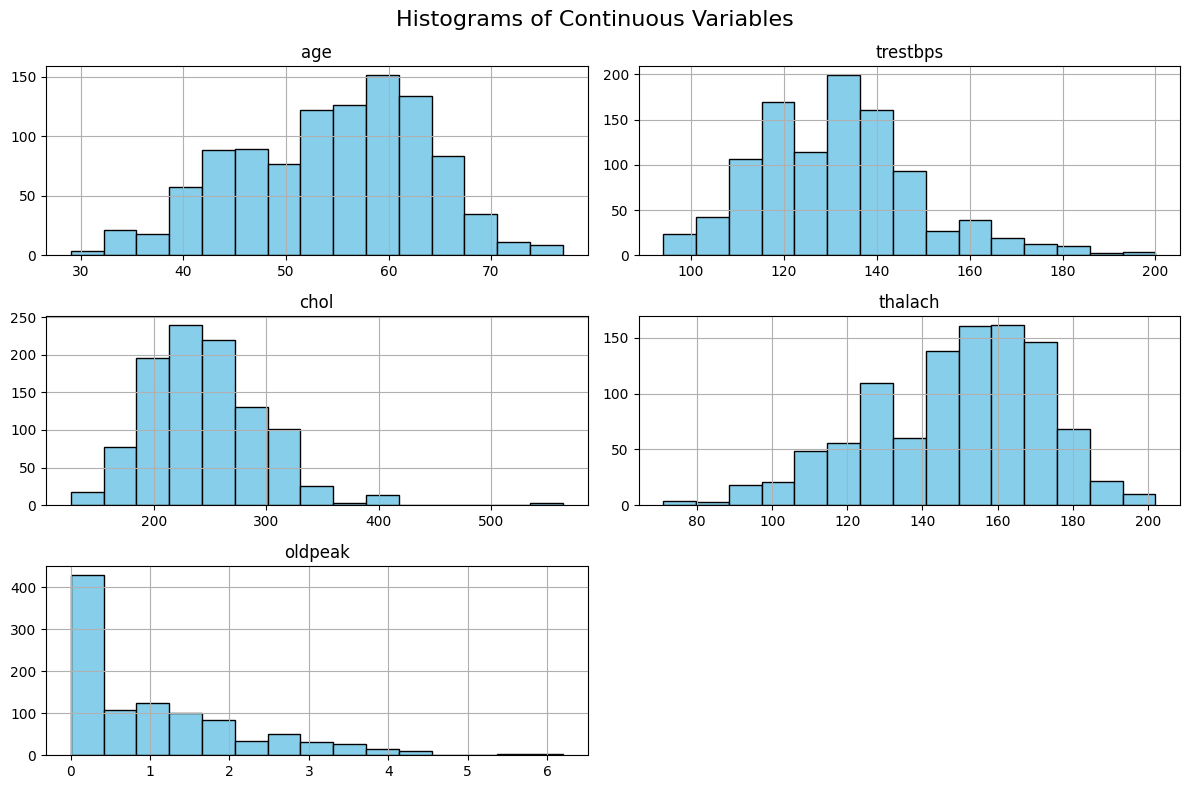

In [11]:
# Plot Histograms for continuous variables
df[numerical_cols].hist(bins=15, figsize=(12, 8), color="skyblue", edgecolor="black")
plt.suptitle("Histograms of Continuous Variables", fontsize=16)
plt.tight_layout()
plt.show()



In [ ]:
# Calculate Skewness and Kurtosis
dist_analysis = pd.DataFrame(
    {
        "Skewness": df[numerical_cols].skew(),
        "Kurtosis": df[numerical_cols].kurtosis(),
    }
)

display(dist_analysis)

# using if else condition for skewness and kurtosis to understand the data 

for col in numerical_cols:
    skewness = dist_analysis.loc[col, "Skewness"]
    kurtosis = dist_analysis.loc[col, "Kurtosis"]
    if skewness > 0:
        skew = "right-skewed"
    elif skewness < 0:
        skew = "left-skewed"
    else:
        skew = "approximately symmetric"
    print(f"{col}: Skewness ({skewness:.2f}) vs Kurtosis ({kurtosis:.2f}) => {skew}")

    # what is skewness and kurtosis?
    # Skewness indicates the asymmetry of the distribution, while Kurtosis measures the peakedness of the distribution
    # -1 to -0.5: left-skewed
    # 0 to 1: approximately symmetric
    # 1 to 2: right-skewed
    # kurtosis  positive: peaked distribution and negative: flat distribution

,Skewness,Kurtosis
age,-0.248866,-0.525618
trestbps,0.739768,0.991221
chol,1.074073,3.996803
thalach,-0.513777,-0.088822
oldpeak,1.210899,1.314471


age: Skewness (-0.25) vs Kurtosis (-0.53) => left-skewed
trestbps: Skewness (0.74) vs Kurtosis (0.99) => right-skewed
chol: Skewness (1.07) vs Kurtosis (4.00) => right-skewed
thalach: Skewness (-0.51) vs Kurtosis (-0.09) => left-skewed
oldpeak: Skewness (1.21) vs Kurtosis (1.31) => right-skewed


# what is skewness and kurtosis?
-  Skewness indicates the asymmetry of the distribution, while Kurtosis measures the peakedness of the distribution
- 1 to -0.5: left-skewed
- 0 to 1: approximately symmetric
- 1 to 2: right-skewed
-  kurtosis  positive: peaked distribution and negative: flat distribution


---
# 4. DATA CLEANING & BIAS 
- Check missing values 
- Identify possible bias 
- Explain reliability and validity 

In [13]:
# Check missing values
missing_values = df.isnull().sum()
print("Missing Values Per Column:\n", missing_values)

# Check for exact duplicate rows (common in this 1025-row dataset)
duplicates = df.duplicated().sum()
print(f"\nDuplicate Rows Found: {duplicates}")

Missing Values Per Column:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Duplicate Rows Found: 723


### Data Quality, Bias, Reliability & Validity

#### 1. Bias (Is the data slanted?)
* **723 Duplicates:** Repeating the same patients overcounts them and tricks the model.
* **Gender Imbalance:** ~70% of patients are men, so the model may not work well for women.

---

#### 2. Reliability (Is the data consistent?)
* **Good:** **0 missing values** means the dataset is complete.
* **Bad:** **723 duplicates** distort the numbers. Fix by running `df.drop_duplicates()`.

---

#### 3. Validity (Does it measure the right things?)
* **Good:** Age, blood pressure, cholesterol, and heart rate are the right medical metrics for heart disease.
* **Bad:** Duplicates and gender imbalance mean model results won't accurately reflect real-world patients.


---
# 5. SAMPLING CONCEPTS 
- Define population vs sample 
- Perform simple sampling 

In [ ]:
# Population: The full dataset (N = 1025)
# Sample: A randomly drawn subset (n = 100)

population_mean_age = df["age"].mean()
sample_df = df.sample(n=100, random_state=42)  # Simple Random Sample
sample_mean_age = sample_df["age"].mean()

print(f"Population Mean Age: {population_mean_age:.2f}")
print(f"Sample Mean Age (n=100): {sample_mean_age:.2f}")
print(
    f"Sampling Error: {abs(population_mean_age - sample_mean_age):.2f} years"
)



Population Mean Age: 54.43
Sample Mean Age (n=100): 55.40
Sampling Error: 0.97 years



---
# 6. CORRELATION ANALYSIS 
- Calculate Pearson and Spearman correlation 
- Interpret relationships 

In [15]:
# Calculate Pearson
pearson_corr = df[numerical_cols].corr(method="pearson")
display(pearson_corr)



,age,trestbps,chol,thalach,oldpeak
age,1.000000,0.271121,0.219823,-0.390227,0.208137
trestbps,0.271121,1.000000,0.127977,-0.039264,0.187434
chol,0.219823,0.127977,1.000000,-0.021772,0.064880
thalach,-0.390227,-0.039264,-0.021772,1.000000,-0.349796
oldpeak,0.208137,0.187434,0.064880,-0.349796,1.000000


- (> 0) means positive correlation 
- (< 0) means negative correlation 
- (0) means no correlation

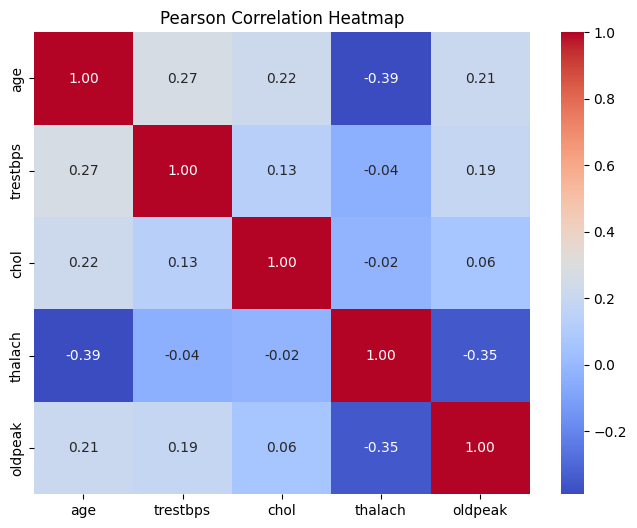

In [16]:
# heatmap for pearson correlation
plt.figure(figsize=(8, 6))
sns.heatmap(pearson_corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Pearson Correlation Heatmap")
plt.show()

### Interpretation of Pearson Correlation Heatmap

* **Age vs. Max Heart Rate (`age` & `thalach` = `-0.39`):** **Strongest negative relationship.** As patients get older, their maximum achieved heart rate tends to go down.
* **Max Heart Rate vs. ST Depression (`thalach` & `oldpeak` = `-0.35`):** Patients who reach higher maximum heart rates usually show lower ST depression (`oldpeak`).
* **Age vs. Blood Pressure (`age` & `trestbps` = `0.27`):** Older patients tend to have slightly higher resting blood pressure.
* **Age vs. Cholesterol (`age` & `chol` = `0.22`):** Older patients tend to have slightly higher cholesterol levels.
* **Weak Correlations:** 
  * Cholesterol (`chol`) shows almost **no link** to max heart rate (`-0.02`) or blood pressure (`0.13`).
  * Most features are weakly correlated, meaning they give unique information without heavily overlapping.

In [35]:
# calculate spearman correlation
spearman_corr = df[numerical_cols].corr(method="spearman")
display(spearman_corr)

# > 0 means a positive relationship, < 0 means a negative relationship and 0 means no relationship

,age,trestbps,chol,thalach,oldpeak
age,1.000000,0.280189,0.203253,-0.382724,0.264500
trestbps,0.280189,1.000000,0.127010,-0.028880,0.146722
chol,0.203253,0.127010,1.000000,-0.054794,0.057102
thalach,-0.382724,-0.028880,-0.054794,1.000000,-0.439987
oldpeak,0.264500,0.146722,0.057102,-0.439987,1.000000


-  (> 0) means a positive relationship,
-   (< 0) means a negative relationship 
-    (0) means no relationship

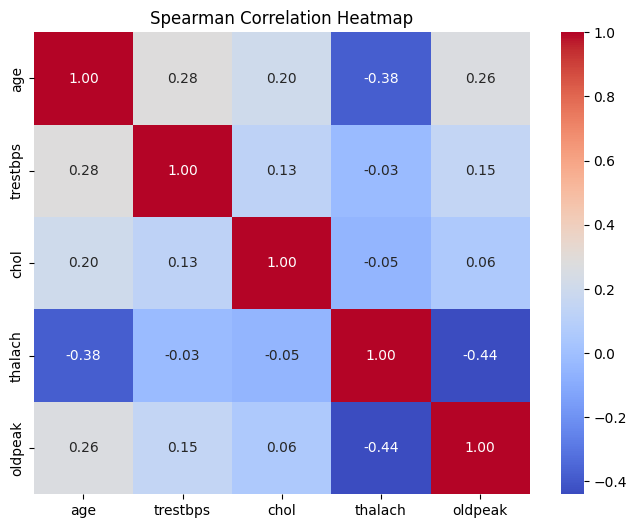

In [17]:
# Spearman (rank-monotonic) correlations
spearman_corr = df[numerical_cols].corr(method="spearman")

# Plot Spearman Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(spearman_corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Spearman Correlation Heatmap")
plt.show()

### Interpretation of Spearman Correlation Heatmap

* **Max Heart Rate vs. ST Depression (`thalach` & `oldpeak` = `-0.44`):** **Strongest negative link.** Patients who achieve higher max heart rates tend to have significantly lower heart strain (`oldpeak`).
* **Age vs. Max Heart Rate (`age` & `thalach` = `-0.38`):** Older patients generally reach lower maximum heart rates.
* **Age vs. Blood Pressure (`age` & `trestbps` = `0.28`):** Older patients tend to rank higher in resting blood pressure.
* **Age vs. ST Depression (`age` & `oldpeak` = `0.26`):** Older patients slightly tend to have higher ST depression readings.
* **Weak Correlations:** 
  * Cholesterol (`chol`) shows almost **no relationship** with max heart rate (`-0.05`) or ST depression (`0.06`).
  * Most features show weak overall rank relationships, meaning each feature brings independent value to the analysis.


---
# 7. HYPOTHESIS TESTING (CORE) 
- Perform t-test 
- Perform Chi-square test 
- Perform ANOVA 
- Define null and alternative hypothesis 


---
- # Hypotheses
- H₀: Sex and heart disease are independent.\
- H₁: Sex and heart disease are associated.
---

In [25]:

# performing chi-square test
chi2, p, dof, expected = stats.chi2_contingency(contingency)
# printing the results
print("Chi-square:", chi2)
print("p-value:", p)

# printing the results using if else condition
if p < 0.05:
    print("Reject the null hypothesis. Sex and heart disease are associated.")
else:
    print("Fail to reject the null hypothesis. Sex and heart disease are independent.")

    

Chi-square: 78.86305133922973
p-value: 6.656820681726434e-19
Reject the null hypothesis. Sex and heart disease are associated.


# what is chi square test
- Chi-square test is a statistical hypothesis test used to determine if there is a significant association between two categorical variables.
    

In [26]:
# performing t-test
t_stat, p_value = stats.ttest_ind(df[df['target'] == 0]['age'], df[df['target'] == 1]['age'])

# printing the results
print("T-statistic:", t_stat)
print("p-value:", p_value)

# what is t-test
# t test is a statistical hypothesis test used to determine if the means of two independent samples are significantly different.

#printing the results using if else condition

if p_value < 0.05:
    print("Reject the null hypothesis. There is a significant difference in age between people with and without heart disease.")
else:
    print("Fail to reject the null hypothesis. There is no significant difference in age between people with and without heart disease.")

T-statistic: 7.535591207962243
p-value: 1.0677220241597e-13
Reject the null hypothesis. There is a significant difference in age between people with and without heart disease.


# what is t-test
- t test is a statistical hypothesis test used to determine if the means of two independent samples are significantly different.

In [27]:
# performing Anova
f_stat, p_value = stats.f_oneway(df[df['target'] == 0]['age'], df[df['target'] == 1]['age'], df[df['target'] == 2]['age'])

# printing the results
print("F-statistic:", f_stat)
print("p-value:", p_value)

# printing the results using if else condition

if p_value < 0.05:
    print("Reject the null hypothesis. There is a significant difference in age between people with different levels of heart disease.")
else:
    print("Fail to reject the null hypothesis. There is no significant difference in age between people with different levels of heart disease.")

 

F-statistic: nan
p-value: nan
Fail to reject the null hypothesis. There is no significant difference in age between people with different levels of heart disease.


C:\Users\tuhid\AppData\Local\Temp\ipykernel_20120\848685739.py:2: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f_stat, p_value = stats.f_oneway(df[df['target'] == 0]['age'], df[df['target'] == 1]['age'], df[df['target'] == 2]['age'])


   # what is ANOVA
- ANOVA (Analysis of Variance) is a statistical test used to determine if the means of three or more independent samples are significantly different.


---
# 8. NORMALITY TESTING 
- Apply Shapiro-Wilk test

In [29]:
# performing Shapiro-Wilk test to check normality
for col in numerical_cols:
    _, p = stats.shapiro(df[col])
    print(f"Shapiro-Wilk test for {col}: p-value = {p}")

# printing the results using if else condition if p-value < 0.05 means the data is not normally distributed

if p < 0.05:
    print("Reject the null hypothesis. The data is not normally distributed.")
else:
    print("Fail to reject the null hypothesis. The data is normally distributed.")

Shapiro-Wilk test for age: p-value = 5.038685420061522e-09
Shapiro-Wilk test for trestbps: p-value = 2.1942341435728597e-15
Shapiro-Wilk test for chol: p-value = 4.0000629780930464e-18
Shapiro-Wilk test for thalach: p-value = 1.5503333439882332e-11
Shapiro-Wilk test for oldpeak: p-value = 4.6685467599581855e-30
Reject the null hypothesis. The data is not normally distributed.



---
# 9. STATISTICAL DECISION MAKING 
- Calculate confidence intervals 
- Explain Type I and Type II errors

In [34]:
#Calculate confidence intervals for numerical columns
confidence = []
for col in numerical_cols:
    confidence.append(stats.t.interval(0.95, len(df[col]) - 1, df[col].mean(), stats.sem(df[col])))



print(confidence)
# using if else condition if confidence interval is less than 0.05 we can reject the null hypothesis

# Display confidence intervals for each numerical column
for i, col in enumerate(numerical_cols):
    ci_lower, ci_upper = confidence[i]
    print(f"{col}: [{ci_lower:.2f}, {ci_upper:.2f}]")

print("\n--- Interpretation ---")
print("Confidence intervals represent the range where the true population mean likely falls (95% confidence).")
print("A narrower interval indicates more precise estimates; a wider interval indicates more uncertainty.")

[(np.float64(53.87809265863525), np.float64(54.99020002429158)), (np.float64(130.5380825423432), np.float64(132.68533209180316)), (np.float64(242.83782103868626), np.float64(249.16217896131374)), (np.float64(147.70409253077275), np.float64(150.5242001521541)), (np.float64(0.9994914954698174), np.float64(1.1435328947740857))]
age: [53.88, 54.99]
trestbps: [130.54, 132.69]
chol: [242.84, 249.16]
thalach: [147.70, 150.52]
oldpeak: [1.00, 1.14]

--- Interpretation ---
Confidence intervals represent the range where the true population mean likely falls (95% confidence).
A narrower interval indicates more precise estimates; a wider interval indicates more uncertainty.


 # what is confidence interval
- confidence interval is a range of values that is likely to contain the true population parameter.

- # Explain Type I and Type II errors in hypothesis testing

-  Type I error: Rejecting the null hypothesis when it is true
-  Type II error: Not rejecting the null hypothesis when it is false